Curator: Elizabeth Osborn

Reviewer: 

Title: A novel stochastic neural network framework for modeling and simulation of within-host Chikungunya virus transmission with latency

Pathogen: CHIKV

DOI: 10.1016/j.knosys.2025.114412

Figure: 4

Outcome: Successful

Notes:  

In [ ]:
variable_names = [
    'S',
    'L',
    'I',
    'V',
    'B',
    'Z'
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [  
    'lam',
    'beta',
    'd',
    'rho',
    'theta',
    'pi',
    'a',
    'epsilon',
    'm',
    'q',
    'r',
    'eta',
    'delta',
    'c',
    'gamma',
    'mu',
    'w',
    'sigma1',
    'sigma2',
    'sigma3',
    'sigma4',
    'sigma5',
    'sigma6'
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S = 1.9,            # Section 5 Figure 1
    L = 1.4,            # Section 5 Figure 1
    I = 0.9,            # Section 5 Figure 1
    V = 1.0,            # Section 5 Figure 1
    B = 1.0,            # Section 5 Figure 1
    Z = 1.2             # Section 5 Figure 1
)

"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    lam = 4,            # Section 5 Figure 1
    beta = 0.10,        # Section 5 Figure 1
    d = 0.1,            # Section 5 Figure 1
    rho = 0.5,          # Section 5 Figure 1    
    theta = 0.5,        # Section 5 Figure 1        
    pi = 0.5,           # Section 5 Figure 1
    a = 0.5,            # Section 5 Figure 1
    epsilon = 0.4441,   # Section 5 Figure 1
    m = 2.020,          # Section 5 Figure 1
    q = 0.596,          # Section 5 Figure 1
    r = 0.442,          # Section 5 Figure 1
    eta = 1.4020,       # Section 5 Figure 1       
    delta = 1.2510,     # Section 5 Figure 1
    c = 1.21290,        # Section 5 Figure 1                                                    
    gamma = 0.50,       # Section 5 Figure 1    
    mu = 1.20,          # Section 5 Figure 1
    w = 0.50,           # Section 5 Figure 1                   
    sigma1 = 0.5,       # Section 5 Figure 2
    sigma2 = 0.5,       # Section 5 Figure 2
    sigma3 = 0.5,       # Section 5 Figure 2
    sigma4 = 0.5,       # Section 5 Figure 2
    sigma5 = 0.5,       # Section 5 Figure 2
    sigma6 = 0.5,       # Section 5 Figure 2
)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 100.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    s, l, i, v, b, z = y
    n = s + l + i + v + b + z
    lam, mu, c, d, gamma, w, epsilon, sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, rho, theta, pi, m, r, q, eta, a, delta, beta = p
    return [
        lam - beta*s*v - d*s,
        (1-rho)*beta*s*v - (theta+pi)*l,
        rho*beta*s*v + pi*l -(a+epsilon*z)*i,
        m*i - q*v - r*v,
        eta - delta*b + c*v*b,
        gamma - mu*z + w*i*z
    ]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    s, l, i, v, b, z = y
    n = s + l + i + v + b + z
    lam, mu, c, d, gamma, w, epsilon, sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, rho, theta, pi, m, r, q, eta, a, delta, beta = p
    return [
        sigma1*s,
        sigma2*l,
        sigma3*i,
        sigma4*v,
        sigma5*b,
        sigma6*z
    ]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [ ]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

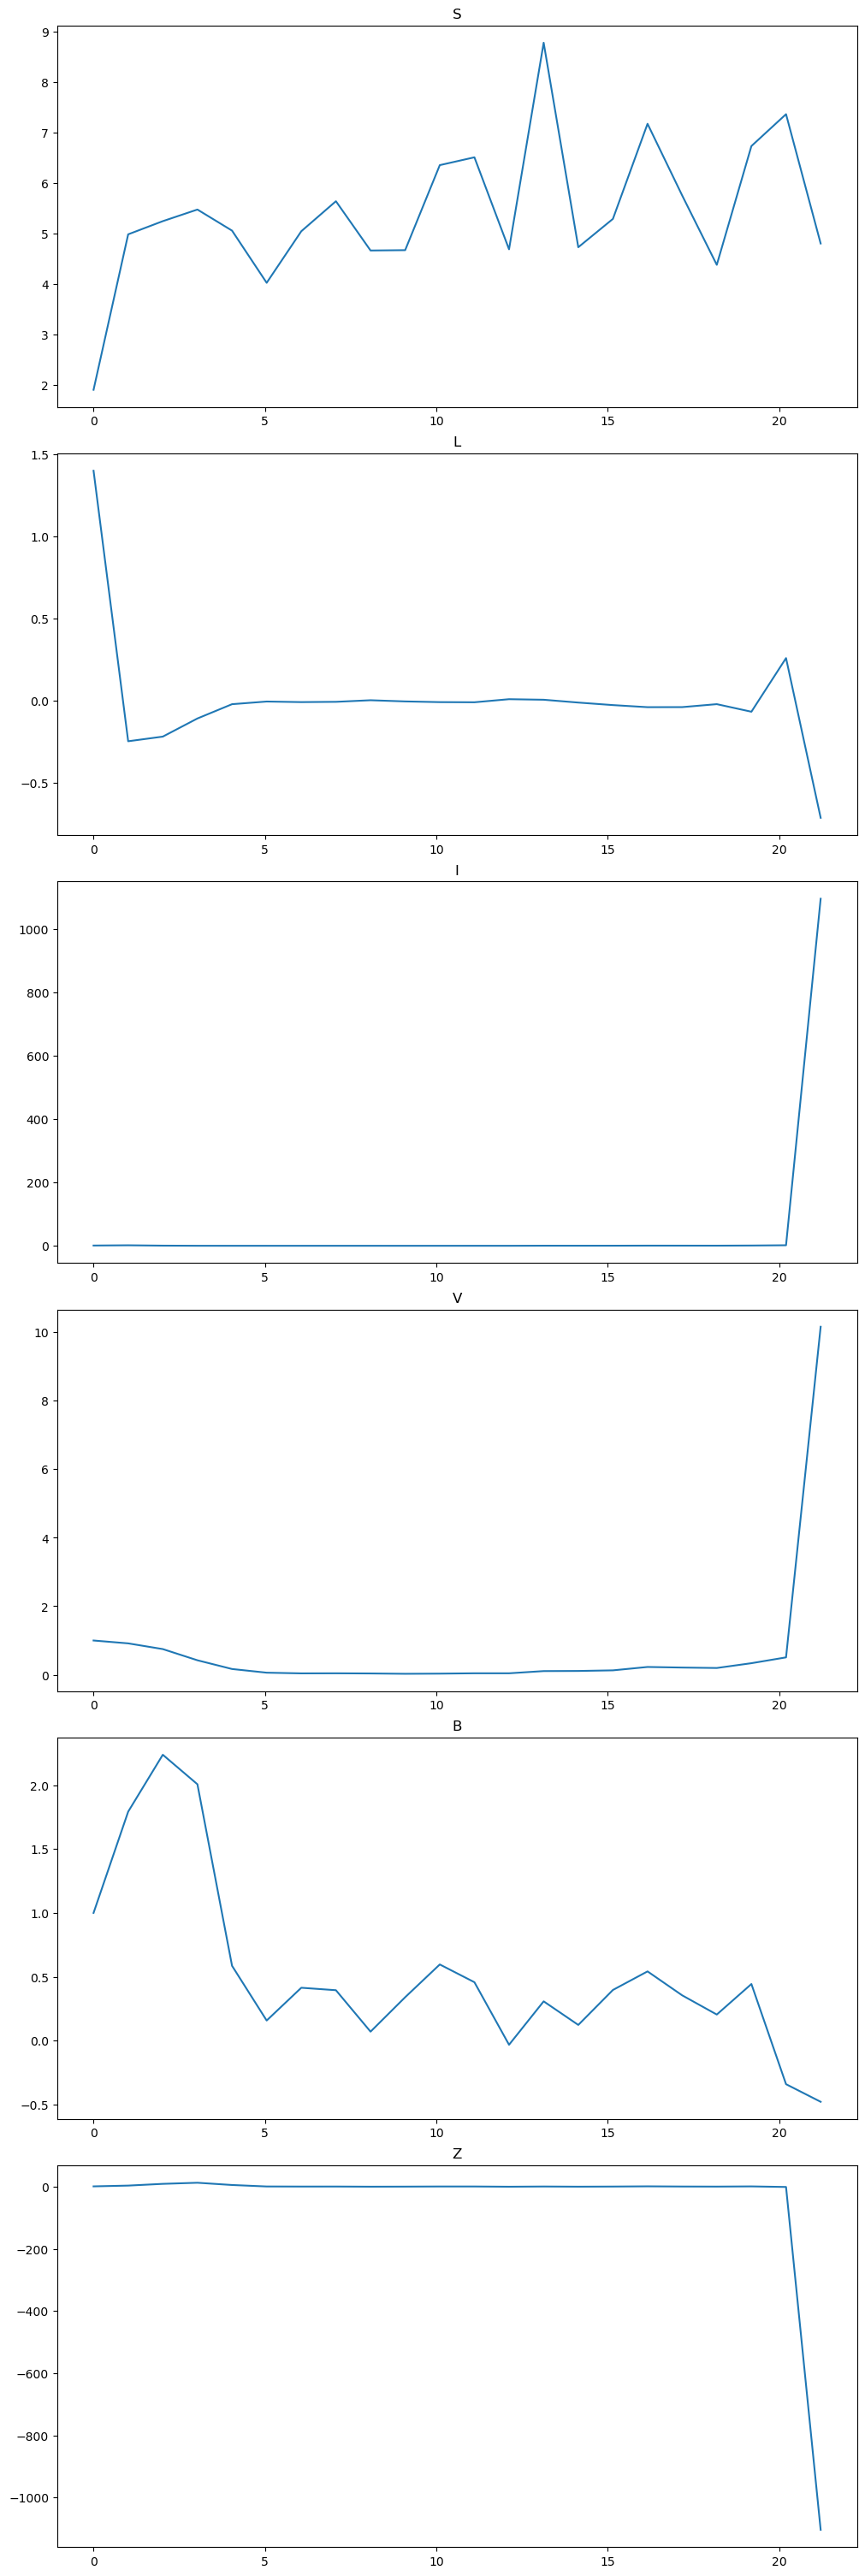

In [ ]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [ ]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
